In [1]:
import duckdb
import random
from functions.analyte import ANALYTES
from networks.cnn_deep import CNNModel
from networks.auto_encoder import AutoencoderModel
from functions.evaluation import evaluate
from functions.full_model import predict


con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT row_id, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set
                 FROM protein_data 
                 WHERE set = 'test'
                 AND observation_nr = 1
                 """).df()
df = df[df['label'].isin([0,1,2,4])]
df = predict(df)
con.close()

#slår ihop oligoklonalt och lätt avvikande
df.loc[df['label']==4,'label'] = 2
df.loc[df['final_prediction']==4,'final_prediction'] = 2


Total parameters: 320,194


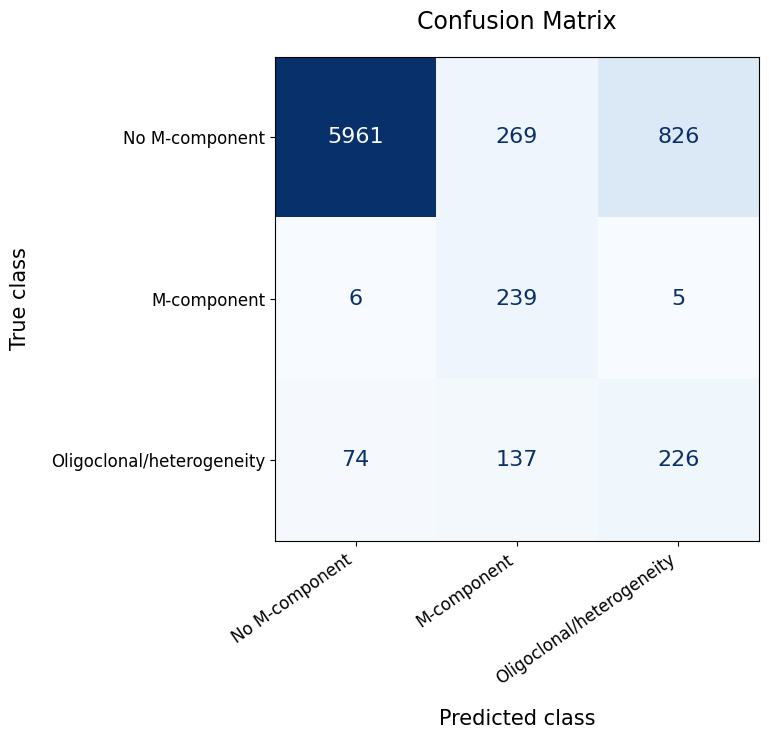

In [2]:
from functions.evaluation import plot_3_by_3_confusion_matrix

plot_3_by_3_confusion_matrix(df)


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

df['type'] = 'normal'



mat = np.zeros((3,3))
total_missclassified = sum(df['label'] != df['final_prediction'])
for i in range(3):
    for j in range(3):
        mat[i,j] = sum((df['label'] == i) & (df['final_prediction'] == j))
        #ids |= set(df.loc[(df['label'] == i) & (df['final_prediction'] == j),'row_id' ].sample(int(np.ceil(mat[i,j]))))

ids = set(df.loc[(df['label'] == 1) & (df['final_prediction'] == 0),'row_id' ]) 
ids |= set(df.loc[(df['label'] == 1) & (df['final_prediction'] == 2),'row_id' ])


ids |= set(df.loc[(df['label'] == 0) & (df['final_prediction'] == 1),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] == 0) & (df['final_prediction'] == 2),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] == 2) & (df['final_prediction'] == 0),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] == 2) & (df['final_prediction'] == 1),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] != df['final_prediction']) & (~df['row_id'].isin(ids)),'row_id' ].sample(1))
df.loc[df['row_id'].isin(ids),'type'] = 'difficult'


ids |= set(df.loc[(df['label'] == 0) & (~df['row_id'].isin(ids)), 'row_id'].sample(50,random_state=42)) 
ids |= set(df.loc[(df['label'] == 1) & (~df['row_id'].isin(ids)), 'row_id'].sample(50,random_state=43))


print(df[df['type'] == 'difficult'].shape[0])

print(len(ids))
print(ids)
df = df[df['row_id'].isin(ids)]
print(len(df))
#df.to_csv('classify-samples.csv')

100
200
{176129, 139781, 100876, 82956, 146962, 144915, 184858, 89115, 90661, 155687, 126504, 119855, 150066, 148018, 2612, 2614, 181305, 7741, 82497, 11330, 33351, 109131, 134732, 57419, 94294, 142422, 146006, 101463, 156247, 162390, 168540, 47197, 22110, 119383, 106076, 79461, 110183, 102904, 128115, 152180, 115, 102398, 110200, 67705, 32378, 129663, 103557, 47750, 140935, 130184, 35462, 39050, 131723, 74893, 43158, 178327, 48279, 96926, 91296, 72865, 51366, 150184, 173225, 17066, 126120, 150186, 64177, 158899, 137908, 42169, 72377, 127162, 46780, 114362, 106174, 82111, 177345, 9923, 83142, 47303, 128712, 82118, 14026, 122572, 153293, 95442, 104150, 68824, 59608, 163035, 28379, 52957, 2782, 178910, 82657, 28899, 112873, 159978, 24811, 6382, 16624, 178929, 66802, 119027, 66803, 147718, 105735, 120584, 157969, 109845, 3862, 73498, 145181, 110367, 56104, 110380, 16685, 3378, 51513, 167740, 91457, 99138, 38211, 128324, 122694, 127302, 34635, 26958, 160080, 166229, 57182, 95586, 84327, 62

In [42]:



df = df[['row_id','type','value','albumin','antitrypsin','orosomukoid','haptoglobin','crp','igg','iga','igm']]
con = duckdb.connect('../application/application.db')
con.execute('DROP TABLE IF EXISTS difficult_cases')
con.execute('CREATE TABLE difficult_cases AS SELECT * FROM df')

con.close()


Total parameters: 320,194


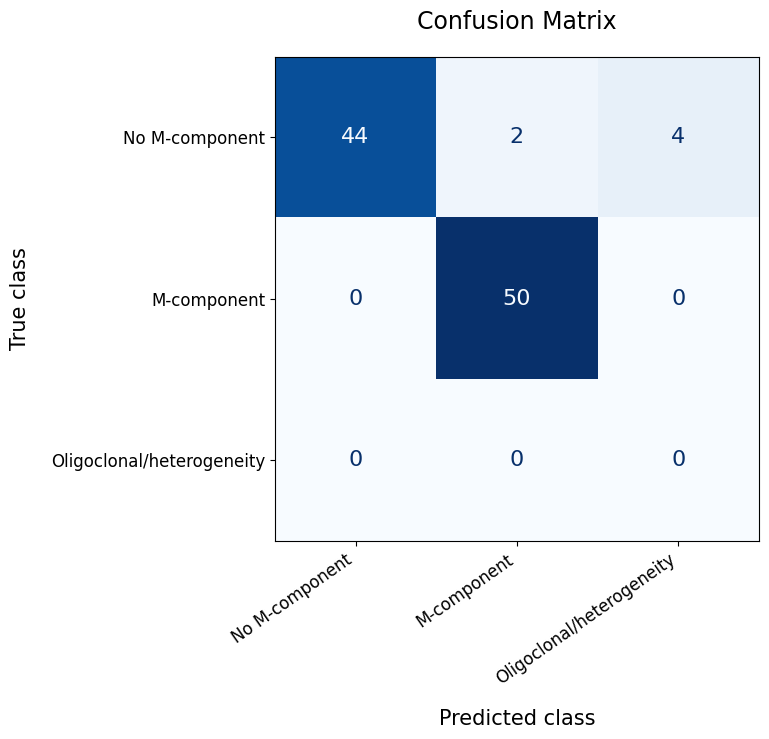

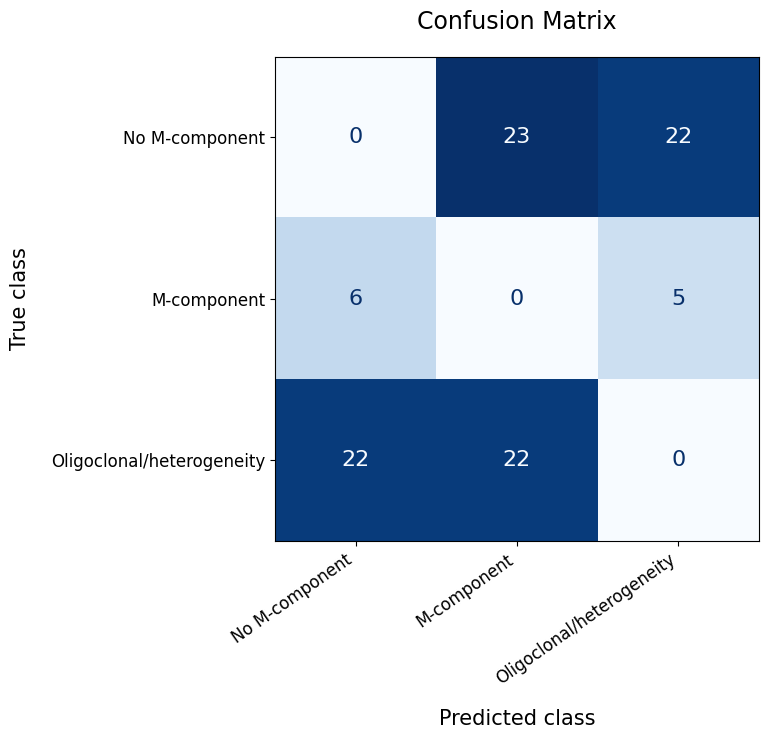

In [3]:
import duckdb
from functions.full_model import predict
from functions.evaluation import plot_3_by_3_confusion_matrix

con = duckdb.connect('../application/application.db')
metadata = con.execute("SELECT row_id,type FROM difficult_cases").fetch_df()
con.close()
con = duckdb.connect('../capillary.db')
con.register("metadata", metadata)


df = con.execute("""
    SELECT row_id, m.type, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label
    FROM protein_data p
    JOIN metadata m USING(row_id)
""").df()

con.close()

df = df.merge(metadata, on='row_id', how='left')
df = predict(df)

df.loc[df['label']==4,'label'] = 2
df.loc[df['final_prediction']==4,'final_prediction'] = 2

easy = df[df['type_x'] == 'normal']
hard = df[df['type_x'] == 'difficult']

plot_3_by_3_confusion_matrix(easy)
plot_3_by_3_confusion_matrix(hard)